# Section 0: Trouble Shooting and Installations

In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.1 MB/s eta 0:00:00


# Section 1: Data Loading and Exploration

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.18MB/s]
100%|██████████| 19.7M/19.7M [00:02<00:00, 9.16MB/s]


=== PneumoniaMNIST ===
Train: (4708, 28, 28), Labels: [1214 3494]
Val: (524, 28, 28), Labels: [135 389]
Test: (624, 28, 28), Labels: [234 390]

=== DermaMNIST ===
Train: (7007, 28, 28, 3), Labels: [ 228  359  769   80  779 4693   99]
Val: (1003, 28, 28, 3), Labels: [ 33  52 110  12 111 671  14]
Test: (2005, 28, 28, 3), Labels: [  66  103  220   23  223 1341   29]


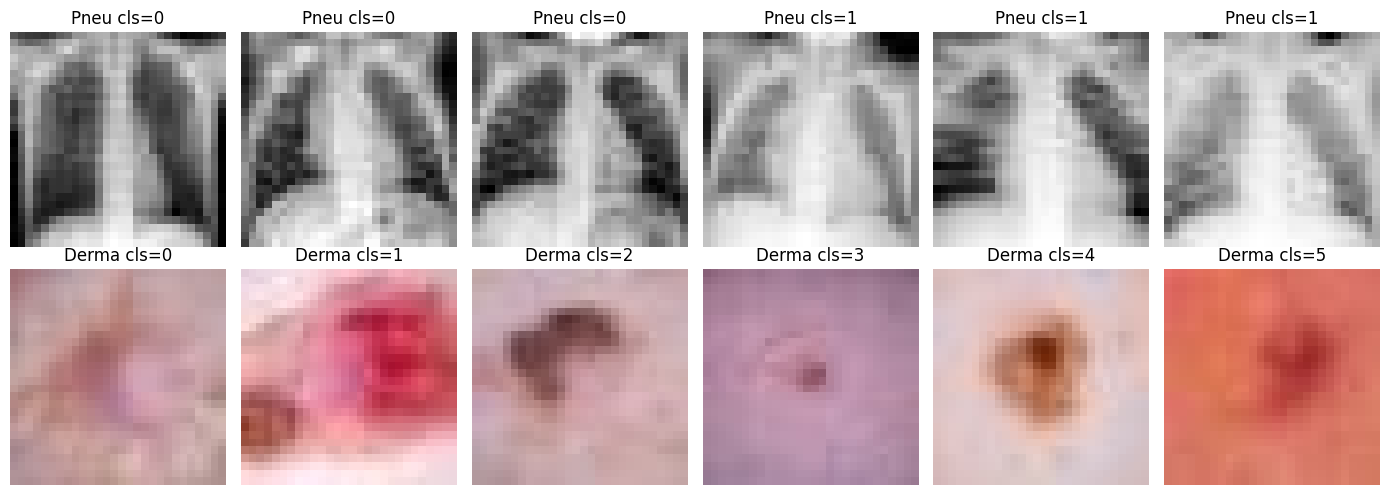

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import medmnist
from medmnist import PneumoniaMNIST, DermaMNIST

pneumonia_train = PneumoniaMNIST(split='train', download=True)
pneumonia_val = PneumoniaMNIST(split='val', download=True)
pneumonia_test = PneumoniaMNIST(split='test', download=True)

derma_train = DermaMNIST(split='train', download=True)
derma_val = DermaMNIST(split='val', download=True)
derma_test = DermaMNIST(split='test', download=True)

def extract_data(dataset):
    imgs = dataset.imgs
    labels = dataset.labels.flatten()
    return imgs, labels

pn_train_imgs, pn_train_labels = extract_data(pneumonia_train)
pn_val_imgs, pn_val_labels = extract_data(pneumonia_val)
pn_test_imgs, pn_test_labels = extract_data(pneumonia_test)

dm_train_imgs, dm_train_labels = extract_data(derma_train)
dm_val_imgs, dm_val_labels = extract_data(derma_val)
dm_test_imgs, dm_test_labels = extract_data(derma_test)

print("=== PneumoniaMNIST ===")
print(f"Train: {pn_train_imgs.shape}, Labels: {np.bincount(pn_train_labels)}")
print(f"Val: {pn_val_imgs.shape}, Labels: {np.bincount(pn_val_labels)}")
print(f"Test: {pn_test_imgs.shape}, Labels: {np.bincount(pn_test_labels)}")

print("\n=== DermaMNIST ===")
print(f"Train: {dm_train_imgs.shape}, Labels: {np.bincount(dm_train_labels)}")
print(f"Val: {dm_val_imgs.shape}, Labels: {np.bincount(dm_val_labels)}")
print(f"Test: {dm_test_imgs.shape}, Labels: {np.bincount(dm_test_labels)}")

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for cls in [0, 1]:
    idxs = np.where(pn_train_labels == cls)[0][:3]
    for j, idx in enumerate(idxs):
        ax = axes[0, cls * 3 + j]
        ax.imshow(pn_train_imgs[idx].squeeze(), cmap='gray')
        ax.set_title(f"Pneu cls={cls}")
        ax.axis('off')

for cls in range(6):
    idxs = np.where(dm_train_labels == cls)[0]
    ax = axes[1, cls]
    ax.imshow(dm_train_imgs[idxs[0]])
    ax.set_title(f"Derma cls={cls}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Section 2: Pre-processing and PCA pipeline

PneumoniaMNIST flattened: (4708, 784)
DermaMNIST flattened: (7007, 2352)


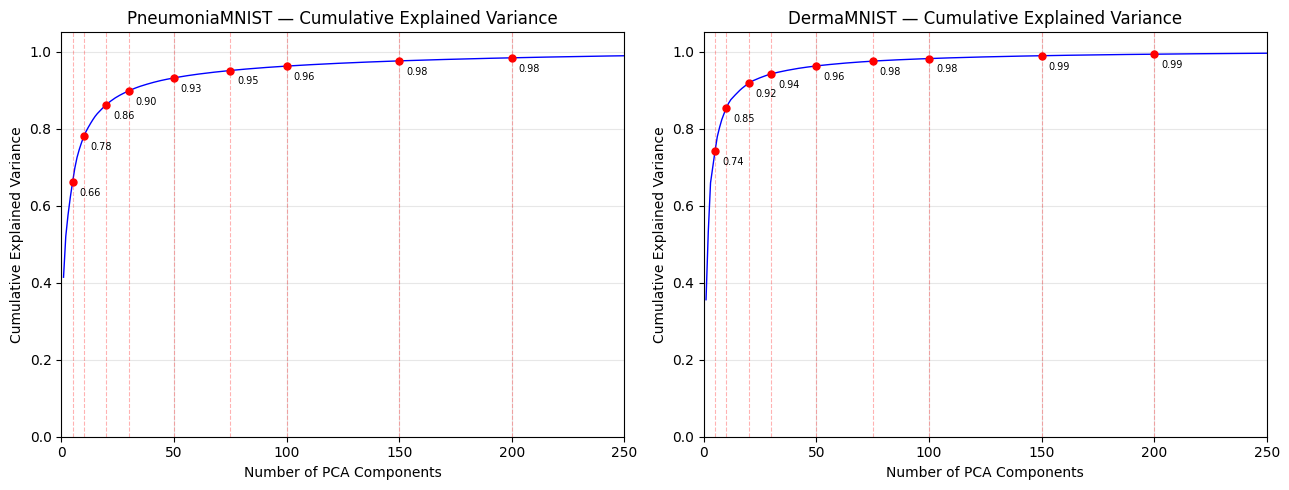

Quick check — PCA to 50 components: train (4708, 50), val (524, 50), test (624, 50)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def flatten_images(imgs):
    return imgs.reshape(imgs.shape[0], -1).astype(np.float64)

pn_train_flat = flatten_images(pn_train_imgs)
pn_val_flat = flatten_images(pn_val_imgs)
pn_test_flat = flatten_images(pn_test_imgs)

dm_train_flat = flatten_images(dm_train_imgs)
dm_val_flat = flatten_images(dm_val_imgs)
dm_test_flat = flatten_images(dm_test_imgs)

print(f"PneumoniaMNIST flattened: {pn_train_flat.shape}")
print(f"DermaMNIST flattened: {dm_train_flat.shape}")

pn_scaler = StandardScaler()
pn_train_scaled = pn_scaler.fit_transform(pn_train_flat)
pn_val_scaled = pn_scaler.transform(pn_val_flat)
pn_test_scaled = pn_scaler.transform(pn_test_flat)

dm_scaler = StandardScaler()
dm_train_scaled = dm_scaler.fit_transform(dm_train_flat)
dm_val_scaled = dm_scaler.transform(dm_val_flat)
dm_test_scaled = dm_scaler.transform(dm_test_flat)

pn_pca_full = PCA().fit(pn_train_scaled)
dm_pca_full = PCA().fit(dm_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pca_components_grid = [5, 10, 20, 30, 50, 75, 100, 150, 200]

for ax, pca_full, title in zip(axes, [pn_pca_full, dm_pca_full],
                                ['PneumoniaMNIST', 'DermaMNIST']):
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    ax.plot(range(1, len(cumvar) + 1), cumvar, 'b-', linewidth=1)
    for d in pca_components_grid:
        if d <= len(cumvar):
            ax.axvline(d, color='red', alpha=0.3, linestyle='--',
                       linewidth=0.8)
            ax.plot(d, cumvar[d - 1], 'ro', markersize=5)
            ax.annotate(f"{cumvar[d-1]:.2f}", (d, cumvar[d - 1]),
                        textcoords="offset points", xytext=(5, -10),
                        fontsize=7)
    ax.set_xlabel('Number of PCA Components')
    ax.set_ylabel('Cumulative Explained Variance')
    ax.set_title(f'{title} — Cumulative Explained Variance')
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

def get_pca_data(n_components, train_scaled, val_scaled, test_scaled):
    pca = PCA(n_components=n_components, svd_solver='randomized',
              random_state=42)
    X_train = pca.fit_transform(train_scaled)
    X_val = pca.transform(val_scaled)
    X_test = pca.transform(test_scaled)
    return X_train, X_val, X_test, pca

X_tr, X_v, X_te, _ = get_pca_data(50, pn_train_scaled, pn_val_scaled, pn_test_scaled)
print(f"Quick check — PCA to 50 components: train {X_tr.shape}, val {X_v.shape}, test {X_te.shape}")

# Section 3: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import time
import warnings
warnings.filterwarnings('ignore')

pca_components_grid = [5, 10, 20, 30, 50, 75, 100, 150, 200]
C_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 1e4]

def evaluate_classifier(clf, X_train, y_train, X_val, y_val, X_test,
                        y_test, multiclass=False):
    start = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - start

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    val_acc = accuracy_score(y_val, clf.predict(X_val))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    if multiclass:
        if hasattr(clf, 'predict_proba'):
            val_auc = roc_auc_score(y_val, clf.predict_proba(X_val),
                                    multi_class='ovr', average='macro')
            test_auc = roc_auc_score(y_test, clf.predict_proba(X_test),
                                     multi_class='ovr', average='macro')
        else:
            val_auc = test_auc = np.nan
        val_f1 = f1_score(y_val, clf.predict(X_val), average='macro')
        test_f1 = f1_score(y_test, clf.predict(X_test), average='macro')
    else:
        if hasattr(clf, 'predict_proba'):
            val_auc = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
            test_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
        else:
            val_auc = test_auc = np.nan
        val_f1 = f1_score(y_val, clf.predict(X_val))
        test_f1 = f1_score(y_test, clf.predict(X_test))

    return {
        'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc,
        'val_auc': val_auc, 'test_auc': test_auc,
        'val_f1': val_f1, 'test_f1': test_f1,
        'train_time': train_time
    }

lr_results_pn = []
print("=== Logistic Regression on PneumoniaMNIST ===")
for d in pca_components_grid:
    X_tr, X_v, X_te, _ = get_pca_data(d, pn_train_scaled,
                                      pn_val_scaled, pn_test_scaled)
    for C in C_grid:
        clf = LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                                 max_iter=5000, random_state=42)
        metrics = evaluate_classifier(clf, X_tr, pn_train_labels,
                                      X_v, pn_val_labels,
                                      X_te, pn_test_labels, multiclass=False)
        metrics['pca_dim'] = d
        metrics['C'] = C
        lr_results_pn.append(metrics)
    print(f"  d={d:>3d} done")

lr_results_dm = []
print("\n=== Logistic Regression on DermaMNIST ===")
for d in pca_components_grid:
    X_tr, X_v, X_te, _ = get_pca_data(d, dm_train_scaled,
                                      dm_val_scaled, dm_test_scaled)
    for C in C_grid:
        clf = LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                                 max_iter=5000,
                                 random_state=42, multi_class='multinomial')
        metrics = evaluate_classifier(clf, X_tr, dm_train_labels,
                                      X_v, dm_val_labels,
                                      X_te, dm_test_labels, multiclass=True)
        metrics['pca_dim'] = d
        metrics['C'] = C
        lr_results_dm.append(metrics)
    print(f"  d={d:>3d} done")

import pandas as pd
lr_df_pn = pd.DataFrame(lr_results_pn)
lr_df_dm = pd.DataFrame(lr_results_dm)

print("\n=== PneumoniaMNIST: Best configs by val accuracy ===")
print(lr_df_pn.sort_values('val_acc', ascending=False).head(5)[
    ['pca_dim', 'C', 'train_acc', 'val_acc', 'test_acc', 'val_auc', 'val_f1',
     'train_time']
].to_string(index=False))

print("\n=== DermaMNIST: Best configs by val accuracy ===")
print(lr_df_dm.sort_values('val_acc', ascending=False).head(5)[
    ['pca_dim', 'C', 'train_acc', 'val_acc', 'test_acc', 'val_auc', 'val_f1',
     'train_time']].to_string(index=False))

=== Logistic Regression on PneumoniaMNIST ===
  d=  5 done
  d= 10 done
  d= 20 done
  d= 30 done
  d= 50 done
  d= 75 done
  d=100 done
  d=150 done
  d=200 done

=== Logistic Regression on DermaMNIST ===
  d=  5 done
  d= 10 done
  d= 20 done
  d= 30 done
  d= 50 done
  d= 75 done
  d=100 done
  d=150 done
  d=200 done

=== PneumoniaMNIST: Best configs by val accuracy ===
 pca_dim     C  train_acc  val_acc  test_acc  val_auc   val_f1  train_time
     200 0.010   0.966865 0.959924  0.847756 0.991964 0.973111    0.384266
     200 0.001   0.955820 0.959924  0.836538 0.988632 0.973111    0.317763
     100 0.010   0.963679 0.959924  0.850962 0.991393 0.973042    0.500227
     150 0.001   0.955607 0.959924  0.838141 0.988594 0.973111    0.157966
     100 0.001   0.955183 0.959924  0.836538 0.988441 0.973111    0.276019

=== DermaMNIST: Best configs by val accuracy ===
 pca_dim       C  train_acc  val_acc  test_acc  val_auc   val_f1  train_time
      75    10.0   0.712573 0.696909  0.698254

In [ ]:
print("=== PneumoniaMNIST: Best C per PCA dimension ===")
for d in pca_components_grid:
    subset = lr_df_pn[lr_df_pn['pca_dim'] == d]
    best = subset.loc[subset['val_acc'].idxmax()]
    print(f"  d={d:>3d} | C={best['C']:>8.0e} | train_acc={best['train_acc']:.4f} | "
          f"val_acc={best['val_acc']:.4f} | test_acc={best['test_acc']:.4f} | "
          f"val_auc={best['val_auc']:.4f} | val_f1={best['val_f1']:.4f}")

print("\n=== DermaMNIST: Best C per PCA dimension ===")
for d in pca_components_grid:
    subset = lr_df_dm[lr_df_dm['pca_dim'] == d]
    best = subset.loc[subset['val_acc'].idxmax()]
    print(f"  d={d:>3d} | C={best['C']:>8.0e} | train_acc={best['train_acc']:.4f} | "
          f"val_acc={best['val_acc']:.4f} | test_acc={best['test_acc']:.4f} | "
          f"val_auc={best['val_auc']:.4f} | val_f1={best['val_f1']:.4f}")

=== PneumoniaMNIST: Best C per PCA dimension ===
  d=  5 | C=   1e-02 | train_acc=0.9102 | val_acc=0.9313 | test_acc=0.8381 | val_auc=0.9693 | val_f1=0.9545
  d= 10 | C=   1e-03 | train_acc=0.9284 | val_acc=0.9408 | test_acc=0.8093 | val_auc=0.9758 | val_f1=0.9604
  d= 20 | C=   1e-03 | train_acc=0.9390 | val_acc=0.9504 | test_acc=0.8269 | val_auc=0.9822 | val_f1=0.9666
  d= 30 | C=   1e-03 | train_acc=0.9486 | val_acc=0.9561 | test_acc=0.8333 | val_auc=0.9864 | val_f1=0.9705
  d= 50 | C=   1e-03 | train_acc=0.9526 | val_acc=0.9580 | test_acc=0.8365 | val_auc=0.9874 | val_f1=0.9718
  d= 75 | C=   1e-03 | train_acc=0.9531 | val_acc=0.9580 | test_acc=0.8365 | val_auc=0.9884 | val_f1=0.9718
  d=100 | C=   1e-03 | train_acc=0.9552 | val_acc=0.9599 | test_acc=0.8365 | val_auc=0.9884 | val_f1=0.9731
  d=150 | C=   1e-03 | train_acc=0.9556 | val_acc=0.9599 | test_acc=0.8381 | val_auc=0.9886 | val_f1=0.9731
  d=200 | C=   1e-03 | train_acc=0.9558 | val_acc=0.9599 | test_acc=0.8365 | val_auc=0.

# Section 4: Linear Discriminant Analysis

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_results_pn = []
print("=== LDA on PneumoniaMNIST ===")
for d in pca_components_grid:
    X_tr, X_v, X_te, _ = get_pca_data(d, pn_train_scaled, pn_val_scaled,
                                      pn_test_scaled)
    clf = LinearDiscriminantAnalysis()
    metrics = evaluate_classifier(clf, X_tr, pn_train_labels, X_v,
                                  pn_val_labels,
                                  X_te, pn_test_labels, multiclass=False)
    metrics['pca_dim'] = d
    lda_results_pn.append(metrics)
    print(f"  d={d:>3d} | train_acc={metrics['train_acc']:.4f} | val_acc={metrics['val_acc']:.4f} | "
          f"test_acc={metrics['test_acc']:.4f} | val_auc={metrics['val_auc']:.4f} | "
          f"val_f1={metrics['val_f1']:.4f} | time={metrics['train_time']:.4f}s")

lda_results_dm = []
print("\n=== LDA on DermaMNIST ===")
for d in pca_components_grid:
    X_tr, X_v, X_te, _ = get_pca_data(d, dm_train_scaled, dm_val_scaled, dm_test_scaled)
    clf = LinearDiscriminantAnalysis()
    metrics = evaluate_classifier(clf, X_tr, dm_train_labels, X_v, dm_val_labels,
                                  X_te, dm_test_labels, multiclass=True)
    metrics['pca_dim'] = d
    lda_results_dm.append(metrics)
    print(f"  d={d:>3d} | train_acc={metrics['train_acc']:.4f} | val_acc={metrics['val_acc']:.4f} | "
          f"test_acc={metrics['test_acc']:.4f} | val_auc={metrics['val_auc']:.4f} | "
          f"val_f1={metrics['val_f1']:.4f} | time={metrics['train_time']:.4f}s")

lda_df_pn = pd.DataFrame(lda_results_pn)
lda_df_dm = pd.DataFrame(lda_results_dm)

=== LDA on PneumoniaMNIST ===
  d=  5 | train_acc=0.9082 | val_acc=0.9256 | test_acc=0.8365 | val_auc=0.9679 | val_f1=0.9506 | time=0.0218s
  d= 10 | train_acc=0.9237 | val_acc=0.9427 | test_acc=0.8141 | val_auc=0.9730 | val_f1=0.9613 | time=0.1166s
  d= 20 | train_acc=0.9350 | val_acc=0.9504 | test_acc=0.8333 | val_auc=0.9787 | val_f1=0.9666 | time=0.4754s
  d= 30 | train_acc=0.9531 | val_acc=0.9504 | test_acc=0.8333 | val_auc=0.9847 | val_f1=0.9666 | time=0.1062s
  d= 50 | train_acc=0.9560 | val_acc=0.9561 | test_acc=0.8526 | val_auc=0.9880 | val_f1=0.9706 | time=0.1406s
  d= 75 | train_acc=0.9592 | val_acc=0.9523 | test_acc=0.8510 | val_auc=0.9908 | val_f1=0.9681 | time=0.3976s
  d=100 | train_acc=0.9609 | val_acc=0.9561 | test_acc=0.8558 | val_auc=0.9918 | val_f1=0.9707 | time=1.0404s
  d=150 | train_acc=0.9624 | val_acc=0.9504 | test_acc=0.8478 | val_auc=0.9915 | val_f1=0.9668 | time=1.5840s
  d=200 | train_acc=0.9656 | val_acc=0.9485 | test_acc=0.8526 | val_auc=0.9898 | val_f1=0.

# Section 4: k-Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
k_grid = [1, 3, 5, 7, 11, 15, 25, 51]
knn_results_pn = []
print("=== kNN on PneumoniaMNIST ===")
for d in pca_components_grid:
    X_tr, X_v, X_te, _ = get_pca_data(d, pn_train_scaled, pn_val_scaled, pn_test_scaled)
    for k in k_grid:
        clf = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        metrics = evaluate_classifier(clf, X_tr, pn_train_labels, X_v, pn_val_labels,
                                      X_te, pn_test_labels, multiclass=False)
        metrics['pca_dim'] = d
        metrics['k'] = k
        knn_results_pn.append(metrics)
    print(f"  d={d:>3d} done")

knn_results_dm = []
print("\n=== kNN on DermaMNIST ===")
for d in pca_components_grid:
    X_tr, X_v, X_te, _ = get_pca_data(d, dm_train_scaled, dm_val_scaled, dm_test_scaled)
    for k in k_grid:
        clf = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        metrics = evaluate_classifier(clf, X_tr, dm_train_labels, X_v, dm_val_labels,
                                      X_te, dm_test_labels, multiclass=True)
        metrics['pca_dim'] = d
        metrics['k'] = k
        knn_results_dm.append(metrics)
    print(f"  d={d:>3d} done")

knn_df_pn = pd.DataFrame(knn_results_pn)
knn_df_dm = pd.DataFrame(knn_results_dm)

print("\n=== PneumoniaMNIST: Best k per PCA dimension ===")
for d in pca_components_grid:
    subset = knn_df_pn[knn_df_pn['pca_dim'] == d]
    best = subset.loc[subset['val_acc'].idxmax()]
    print(f"  d={d:>3d} | k={int(best['k']):>3d} | train_acc={best['train_acc']:.4f} | "
          f"val_acc={best['val_acc']:.4f} | test_acc={best['test_acc']:.4f} | "
          f"val_auc={best['val_auc']:.4f} | val_f1={best['val_f1']:.4f}")

print("\n=== DermaMNIST: Best k per PCA dimension ===")
for d in pca_components_grid:
    subset = knn_df_dm[knn_df_dm['pca_dim'] == d]
    best = subset.loc[subset['val_acc'].idxmax()]
    print(f"  d={d:>3d} | k={int(best['k']):>3d} | train_acc={best['train_acc']:.4f} | "
          f"val_acc={best['val_acc']:.4f} | test_acc={best['test_acc']:.4f} | "
          f"val_auc={best['val_auc']:.4f} | val_f1={best['val_f1']:.4f}")

=== kNN on PneumoniaMNIST ===
  d=  5 done
  d= 10 done
  d= 20 done
  d= 30 done
  d= 50 done
  d= 75 done
  d=100 done
  d=150 done
  d=200 done

=== kNN on DermaMNIST ===
  d=  5 done
  d= 10 done
  d= 20 done
  d= 30 done
  d= 50 done
  d= 75 done
  d=100 done
  d=150 done
  d=200 done

=== PneumoniaMNIST: Best k per PCA dimension ===
  d=  5 | k= 15 | train_acc=0.9280 | val_acc=0.9447 | test_acc=0.8269 | val_auc=0.9730 | val_f1=0.9630
  d= 10 | k= 15 | train_acc=0.9469 | val_acc=0.9523 | test_acc=0.8237 | val_auc=0.9783 | val_f1=0.9682
  d= 20 | k= 11 | train_acc=0.9528 | val_acc=0.9523 | test_acc=0.8365 | val_auc=0.9782 | val_f1=0.9680
  d= 30 | k=  7 | train_acc=0.9639 | val_acc=0.9561 | test_acc=0.8397 | val_auc=0.9731 | val_f1=0.9706
  d= 50 | k=  3 | train_acc=0.9718 | val_acc=0.9580 | test_acc=0.8478 | val_auc=0.9582 | val_f1=0.9718
  d= 75 | k=  7 | train_acc=0.9669 | val_acc=0.9599 | test_acc=0.8365 | val_auc=0.9767 | val_f1=0.9732
  d=100 | k= 25 | train_acc=0.9528 | val_

# Section 5: Support Vector Machine

In [ ]:
from sklearn.svm import SVC

C_grid_svm_full = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 1e4]
gamma_grid_full = [1e-4, 1e-3, 1e-2, 1e-1, 1]

svm_results_pn = []
print("=== SVM-RBF Full Grid — PneumoniaMNIST ===")
for d in pca_components_grid:
    X_tr, X_v, X_te, _ = get_pca_data(d, pn_train_scaled,
                                      pn_val_scaled, pn_test_scaled)
    count = 0
    total = len(C_grid_svm_full) * len(gamma_grid_full)
    for C in C_grid_svm_full:
        for gamma in gamma_grid_full:
            clf = SVC(C=C, gamma=gamma, kernel='rbf', probability=True,
                      cache_size=1000, random_state=42)
            metrics = evaluate_classifier(clf, X_tr, pn_train_labels,
                                          X_v, pn_val_labels,
                                          X_te, pn_test_labels,
                                          multiclass=False)
            metrics['pca_dim'] = d
            metrics['C'] = C
            metrics['gamma'] = gamma
            svm_results_pn.append(metrics)
            count += 1
    print(f"  d={d:>3d} done ({count}/{total} configs)")

svm_df_pn = pd.DataFrame(svm_results_pn)

print("\n=== PneumoniaMNIST — Best (C, gamma) per PCA dimension ===")
for d in pca_components_grid:
    subset = svm_df_pn[svm_df_pn['pca_dim'] == d]
    best = subset.loc[subset['val_acc'].idxmax()]
    print(f"  d={d:>3d} | C={best['C']:>8.0e} | gamma={best['gamma']:>8.0e} | "
          f"train_acc={best['train_acc']:.4f} | val_acc={best['val_acc']:.4f} | "
          f"test_acc={best['test_acc']:.4f} | val_auc={best['val_auc']:.4f} | "
          f"val_f1={best['val_f1']:.4f} | time={best['train_time']:.2f}s")

=== SVM-RBF Full Grid — PneumoniaMNIST ===
  d=  5 done (45/45 configs)
  d= 10 done (45/45 configs)
  d= 20 done (45/45 configs)
  d= 30 done (45/45 configs)
  d= 50 done (45/45 configs)
  d= 75 done (45/45 configs)
  d=100 done (45/45 configs)
  d=150 done (45/45 configs)
  d=200 done (45/45 configs)

=== PneumoniaMNIST — Best (C, gamma) per PCA dimension ===
  d=  5 | C=   1e+00 | gamma=   1e-02 | train_acc=0.9405 | val_acc=0.9427 | test_acc=0.8269 | val_auc=0.9509 | val_f1=0.9618 | time=1.31s
  d= 10 | C=   1e+01 | gamma=   1e-03 | train_acc=0.9601 | val_acc=0.9542 | test_acc=0.8285 | val_auc=0.9865 | val_f1=0.9695 | time=1.41s
  d= 20 | C=   1e+01 | gamma=   1e-04 | train_acc=0.9526 | val_acc=0.9656 | test_acc=0.8429 | val_auc=0.9866 | val_f1=0.9769 | time=1.06s
  d= 30 | C=   1e+01 | gamma=   1e-03 | train_acc=0.9928 | val_acc=0.9771 | test_acc=0.8606 | val_auc=0.9951 | val_f1=0.9845 | time=1.35s
  d= 50 | C=   1e+03 | gamma=   1e-03 | train_acc=1.0000 | val_acc=0.9714 | test_acc

# Section 6: VC Bound

In [ ]:
def vc_bound(N, d_vc, delta=0.05):
    return np.sqrt((8 / N) * (d_vc * np.log(2 * np.e * N / d_vc) + np.log(4 / delta)))

N_pn = len(pn_train_labels)
N_dm = len(dm_train_labels)

print(f"PneumoniaMNIST training size: N = {N_pn}")
print(f"DermaMNIST training size: N = {N_dm}")

print("\n=== PneumoniaMNIST — VC Bound vs Empirical Gap ===")
print(f"{'d':>5s} | {'d_VC':>5s} | {'VC Bound':>10s} | {'LR Gap':>10s} | {'LDA Gap':>10s} | {'Vacuous?':>9s}")
print("-" * 65)
for d in pca_components_grid:
    d_vc = d + 1
    bound = vc_bound(N_pn, d_vc)

    lr_sub = lr_df_pn[lr_df_pn['pca_dim'] == d]
    lr_best = lr_sub.loc[lr_sub['val_acc'].idxmax()]
    lr_gap = abs(lr_best['test_acc'] - lr_best['train_acc'])

    lda_row = lda_df_pn[lda_df_pn['pca_dim'] == d].iloc[0]
    lda_gap = abs(lda_row['test_acc'] - lda_row['train_acc'])

    vacuous = "YES" if bound > 1.0 else "no"
    print(f"{d:>5d} | {d_vc:>5d} | {bound:>10.4f} | {lr_gap:>10.4f} | {lda_gap:>10.4f} | {vacuous:>9s}")

print("\n=== DermaMNIST — VC Bound vs Empirical Gap ===")
print(f"{'d':>5s} | {'d_VC':>5s} | {'VC Bound':>10s} | {'LR Gap':>10s} | {'LDA Gap':>10s} | {'Vacuous?':>9s}")
print("-" * 65)
for d in pca_components_grid:
    d_vc = d + 1
    bound = vc_bound(N_dm, d_vc)

    lr_sub = lr_df_dm[lr_df_dm['pca_dim'] == d]
    lr_best = lr_sub.loc[lr_sub['val_acc'].idxmax()]
    lr_gap = abs(lr_best['test_acc'] - lr_best['train_acc'])

    lda_row = lda_df_dm[lda_df_dm['pca_dim'] == d].iloc[0]
    lda_gap = abs(lda_row['test_acc'] - lda_row['train_acc'])

    vacuous = "YES" if bound > 1.0 else "no"
    print(f"{d:>5d} | {d_vc:>5d} | {bound:>10.4f} | {lr_gap:>10.4f} | {lda_gap:>10.4f} | {vacuous:>9s}")

PneumoniaMNIST training size: N = 4708
DermaMNIST training size: N = 7007

=== PneumoniaMNIST — VC Bound vs Empirical Gap ===
    d |  d_VC |   VC Bound |     LR Gap |    LDA Gap |  Vacuous?
-----------------------------------------------------------------
    5 |     6 |     0.3044 |     0.0720 |     0.0717 |        no
   10 |    11 |     0.3903 |     0.1191 |     0.1096 |        no
   20 |    21 |     0.5109 |     0.1121 |     0.1017 |        no
   30 |    31 |     0.6010 |     0.1153 |     0.1197 |        no
   50 |    51 |     0.7391 |     0.1161 |     0.1035 |        no
   75 |    76 |     0.8712 |     0.1165 |     0.1083 |        no
  100 |   101 |     0.9785 |     0.1186 |     0.1051 |        no
  150 |   151 |     1.1509 |     0.1175 |     0.1146 |       YES
  200 |   201 |     1.2895 |     0.1193 |     0.1130 |       YES

=== DermaMNIST — VC Bound vs Empirical Gap ===
    d |  d_VC |   VC Bound |     LR Gap |    LDA Gap |  Vacuous?
---------------------------------------------

# Section 8: Visualizations

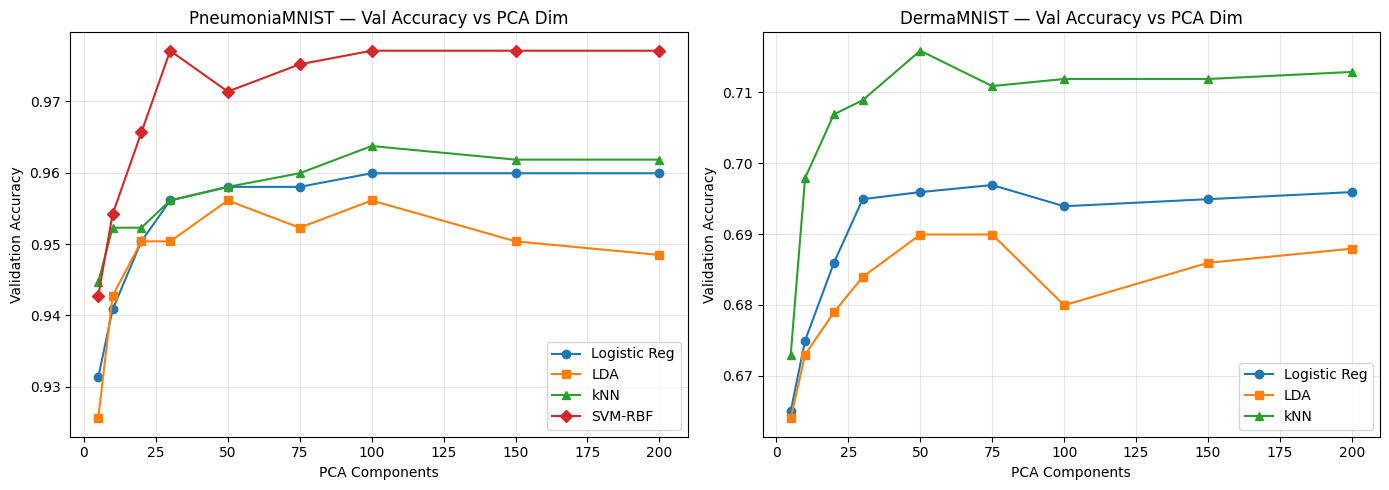

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
lr_best_pn = lr_df_pn.groupby('pca_dim').apply(lambda x: x.loc[x['val_acc'].idxmax()]).reset_index(drop=True)
lda_best_pn = lda_df_pn.copy()
knn_best_pn = knn_df_pn.groupby('pca_dim').apply(lambda x: x.loc[x['val_acc'].idxmax()]).reset_index(drop=True)
svm_best_pn = svm_df_pn.groupby('pca_dim').apply(lambda x: x.loc[x['val_acc'].idxmax()]).reset_index(drop=True)

ax.plot(lr_best_pn['pca_dim'], lr_best_pn['val_acc'], 'o-', label='Logistic Reg')
ax.plot(lda_best_pn['pca_dim'], lda_best_pn['val_acc'], 's-', label='LDA')
ax.plot(knn_best_pn['pca_dim'], knn_best_pn['val_acc'], '^-', label='kNN')
ax.plot(svm_best_pn['pca_dim'], svm_best_pn['val_acc'], 'D-', label='SVM-RBF')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Validation Accuracy')
ax.set_title('PneumoniaMNIST — Val Accuracy vs PCA Dim')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
lr_best_dm = lr_df_dm.groupby('pca_dim').apply(lambda x: x.loc[x['val_acc'].idxmax()]).reset_index(drop=True)
lda_best_dm = lda_df_dm.copy()
knn_best_dm = knn_df_dm.groupby('pca_dim').apply(lambda x: x.loc[x['val_acc'].idxmax()]).reset_index(drop=True)

ax.plot(lr_best_dm['pca_dim'], lr_best_dm['val_acc'], 'o-', label='Logistic Reg')
ax.plot(lda_best_dm['pca_dim'], lda_best_dm['val_acc'], 's-', label='LDA')
ax.plot(knn_best_dm['pca_dim'], knn_best_dm['val_acc'], '^-', label='kNN')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Validation Accuracy')
ax.set_title('DermaMNIST — Val Accuracy vs PCA Dim')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

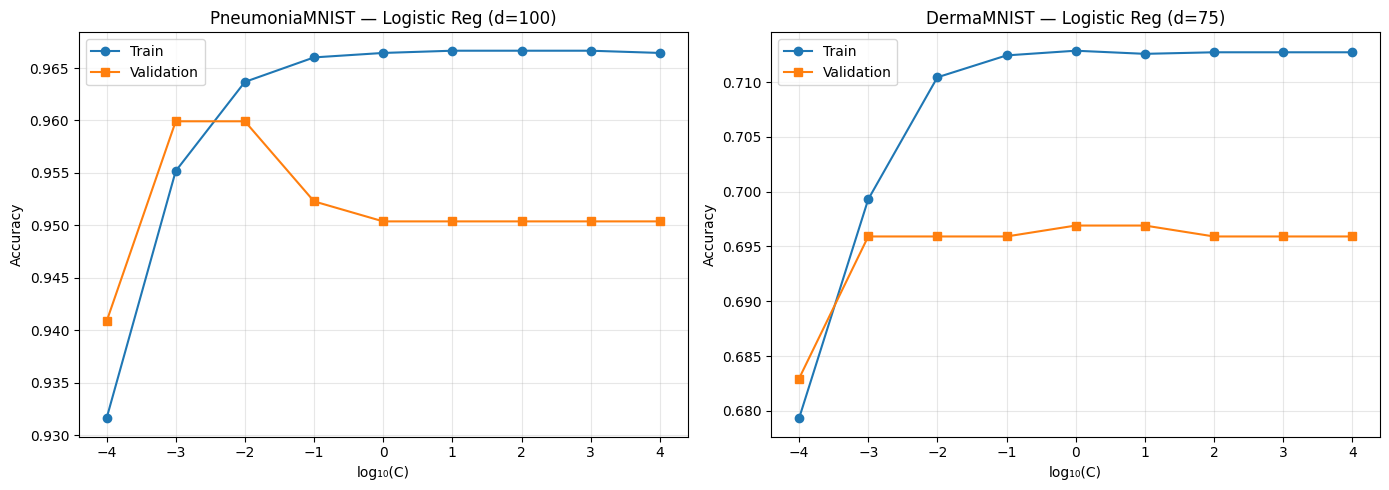

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

d_plot = 100
ax = axes[0]
subset = lr_df_pn[lr_df_pn['pca_dim'] == d_plot].sort_values('C')
ax.plot(np.log10(subset['C']), subset['train_acc'], 'o-', label='Train')
ax.plot(np.log10(subset['C']), subset['val_acc'], 's-', label='Validation')
ax.set_xlabel('log₁₀(C)')
ax.set_ylabel('Accuracy')
ax.set_title(f'PneumoniaMNIST — Logistic Reg (d={d_plot})')
ax.legend()
ax.grid(True, alpha=0.3)

d_plot = 75
ax = axes[1]
subset = lr_df_dm[lr_df_dm['pca_dim'] == d_plot].sort_values('C')
ax.plot(np.log10(subset['C']), subset['train_acc'], 'o-', label='Train')
ax.plot(np.log10(subset['C']), subset['val_acc'], 's-', label='Validation')
ax.set_xlabel('log₁₀(C)')
ax.set_ylabel('Accuracy')
ax.set_title(f'DermaMNIST — Logistic Reg (d={d_plot})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

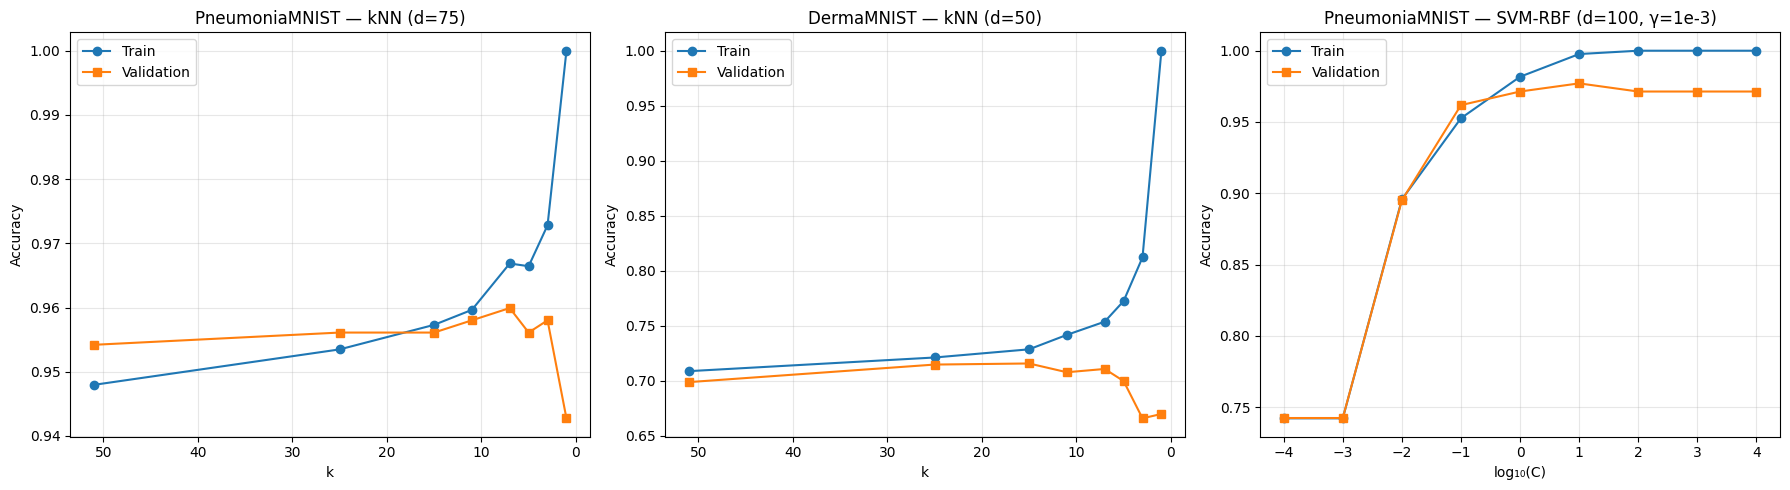

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
d_plot = 75
ax = axes[0]
subset = knn_df_pn[knn_df_pn['pca_dim'] == d_plot].sort_values('k')
ax.plot(subset['k'], subset['train_acc'], 'o-', label='Train')
ax.plot(subset['k'], subset['val_acc'], 's-', label='Validation')
ax.set_xlabel('k')
ax.set_ylabel('Accuracy')
ax.set_title(f'PneumoniaMNIST — kNN (d={d_plot})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
d_plot = 50
ax = axes[1]
subset = knn_df_dm[knn_df_dm['pca_dim'] == d_plot].sort_values('k')
ax.plot(subset['k'], subset['train_acc'], 'o-', label='Train')
ax.plot(subset['k'], subset['val_acc'], 's-', label='Validation')
ax.set_xlabel('k')
ax.set_ylabel('Accuracy')
ax.set_title(f'DermaMNIST — kNN (d={d_plot})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

d_plot = 100
gamma_plot = 1e-3
ax = axes[2]
subset = svm_df_pn[(svm_df_pn['pca_dim'] == d_plot) & (svm_df_pn['gamma'] == gamma_plot)].sort_values('C')
ax.plot(np.log10(subset['C']), subset['train_acc'], 'o-', label='Train')
ax.plot(np.log10(subset['C']), subset['val_acc'], 's-', label='Validation')
ax.set_xlabel('log₁₀(C)')
ax.set_ylabel('Accuracy')
ax.set_title(f'PneumoniaMNIST — SVM-RBF (d={d_plot}, γ=1e-3)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

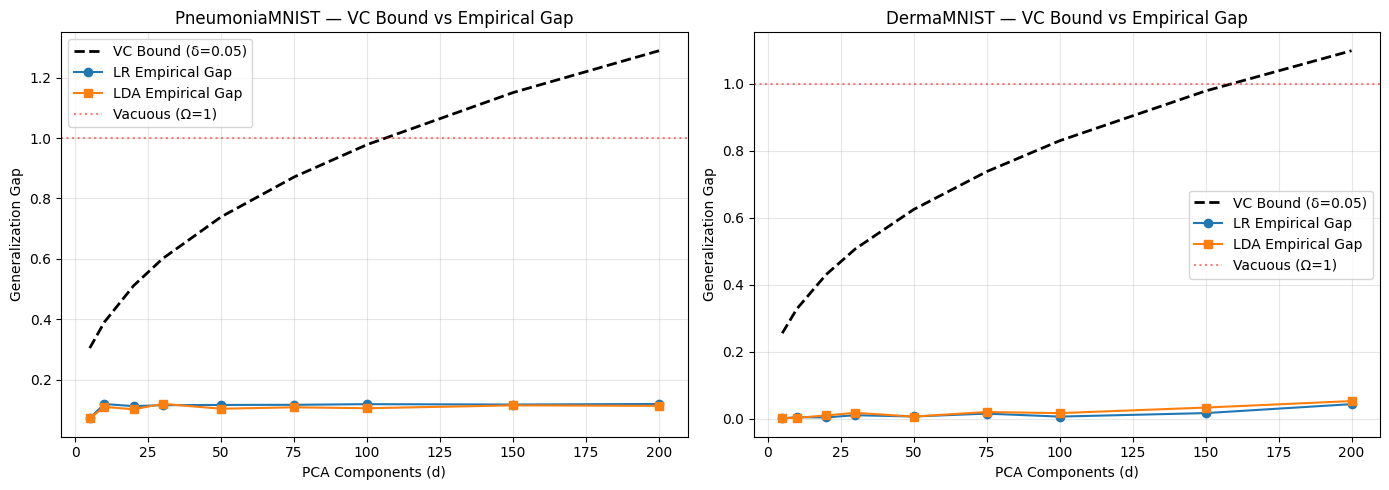

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

d_values = np.array(pca_components_grid)
ax = axes[0]
vc_bounds_pn = [vc_bound(N_pn, d + 1) for d in d_values]

lr_gaps_pn = []
lda_gaps_pn = []
for d in d_values:
    lr_sub = lr_df_pn[lr_df_pn['pca_dim'] == d]
    lr_best = lr_sub.loc[lr_sub['val_acc'].idxmax()]
    lr_gaps_pn.append(abs(lr_best['test_acc'] - lr_best['train_acc']))

    lda_row = lda_df_pn[lda_df_pn['pca_dim'] == d].iloc[0]
    lda_gaps_pn.append(abs(lda_row['test_acc'] - lda_row['train_acc']))

ax.plot(d_values, vc_bounds_pn, 'k--', linewidth=2, label='VC Bound (δ=0.05)')
ax.plot(d_values, lr_gaps_pn, 'o-', label='LR Empirical Gap')
ax.plot(d_values, lda_gaps_pn, 's-', label='LDA Empirical Gap')
ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.5, label='Vacuous (Ω=1)')
ax.set_xlabel('PCA Components (d)')
ax.set_ylabel('Generalization Gap')
ax.set_title('PneumoniaMNIST — VC Bound vs Empirical Gap')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
vc_bounds_dm = [vc_bound(N_dm, d + 1) for d in d_values]

lr_gaps_dm = []
lda_gaps_dm = []
for d in d_values:
    lr_sub = lr_df_dm[lr_df_dm['pca_dim'] == d]
    lr_best = lr_sub.loc[lr_sub['val_acc'].idxmax()]
    lr_gaps_dm.append(abs(lr_best['test_acc'] - lr_best['train_acc']))

    lda_row = lda_df_dm[lda_df_dm['pca_dim'] == d].iloc[0]
    lda_gaps_dm.append(abs(lda_row['test_acc'] - lda_row['train_acc']))

ax.plot(d_values, vc_bounds_dm, 'k--', linewidth=2, label='VC Bound (δ=0.05)')
ax.plot(d_values, lr_gaps_dm, 'o-', label='LR Empirical Gap')
ax.plot(d_values, lda_gaps_dm, 's-', label='LDA Empirical Gap')
ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.5, label='Vacuous (Ω=1)')
ax.set_xlabel('PCA Components (d)')
ax.set_ylabel('Generalization Gap')
ax.set_title('DermaMNIST — VC Bound vs Empirical Gap')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

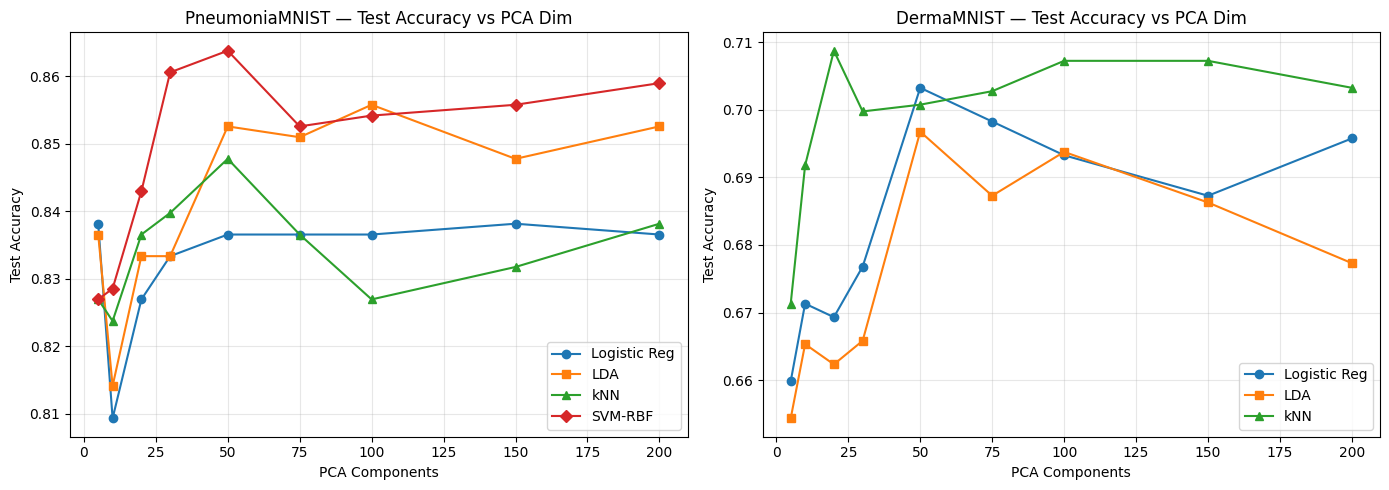


SUMMARY — Best Configuration Per Classifier (selected by validation accuracy)

--- PneumoniaMNIST ---
Classifier        PCA Hyperparams           Val Acc  Test Acc  Val AUC   Val F1
---------------------------------------------------------------------------
Logistic Reg      100 C=0.001                0.9599    0.8365   0.9884   0.9731
LDA                50 —                      0.9561    0.8526   0.9880   0.9706
kNN               100 k=25                   0.9637    0.8269   0.9879   0.9759
SVM-RBF            30 C=10.0, γ=0.001        0.9771    0.8606   0.9951   0.9845

--- DermaMNIST ---
Classifier        PCA Hyperparams           Val Acc  Test Acc  Val AUC   Val F1
---------------------------------------------------------------------------
Logistic Reg       75 C=1.0                  0.6969    0.6983   0.8670   0.3420
LDA                50 —                      0.6899    0.6968   0.8698   0.3135
kNN                50 k=15                   0.7159    0.7007   0.7926   0.2888


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(lr_best_pn['pca_dim'], lr_best_pn['test_acc'], 'o-', label='Logistic Reg')
ax.plot(lda_best_pn['pca_dim'], lda_best_pn['test_acc'], 's-', label='LDA')
ax.plot(knn_best_pn['pca_dim'], knn_best_pn['test_acc'], '^-', label='kNN')
ax.plot(svm_best_pn['pca_dim'], svm_best_pn['test_acc'], 'D-', label='SVM-RBF')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Test Accuracy')
ax.set_title('PneumoniaMNIST — Test Accuracy vs PCA Dim')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(lr_best_dm['pca_dim'], lr_best_dm['test_acc'], 'o-', label='Logistic Reg')
ax.plot(lda_best_dm['pca_dim'], lda_best_dm['test_acc'], 's-', label='LDA')
ax.plot(knn_best_dm['pca_dim'], knn_best_dm['test_acc'], '^-', label='kNN')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Test Accuracy')
ax.set_title('DermaMNIST — Test Accuracy vs PCA Dim')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*85)
print("SUMMARY — Best Configuration Per Classifier (selected by validation accuracy)")
print("="*85)

print("\n--- PneumoniaMNIST ---")
print(f"{'Classifier':<15s} {'PCA':>5s} {'Hyperparams':<20s} {'Val Acc':>8s} {'Test Acc':>9s} {'Val AUC':>8s} {'Val F1':>8s}")
print("-"*75)

best = lr_df_pn.loc[lr_df_pn['val_acc'].idxmax()]
print(f"{'Logistic Reg':<15s} {int(best['pca_dim']):>5d} {'C='+str(best['C']):<20s} {best['val_acc']:>8.4f} {best['test_acc']:>9.4f} {best['val_auc']:>8.4f} {best['val_f1']:>8.4f}")

best = lda_df_pn.loc[lda_df_pn['val_acc'].idxmax()]
print(f"{'LDA':<15s} {int(best['pca_dim']):>5d} {'—':<20s} {best['val_acc']:>8.4f} {best['test_acc']:>9.4f} {best['val_auc']:>8.4f} {best['val_f1']:>8.4f}")

best = knn_df_pn.loc[knn_df_pn['val_acc'].idxmax()]
print(f"{'kNN':<15s} {int(best['pca_dim']):>5d} {'k='+str(int(best['k'])):<20s} {best['val_acc']:>8.4f} {best['test_acc']:>9.4f} {best['val_auc']:>8.4f} {best['val_f1']:>8.4f}")

best = svm_df_pn.loc[svm_df_pn['val_acc'].idxmax()]
print(f"{'SVM-RBF':<15s} {int(best['pca_dim']):>5d} {'C='+str(best['C'])+', γ='+str(best['gamma']):<20s} {best['val_acc']:>8.4f} {best['test_acc']:>9.4f} {best['val_auc']:>8.4f} {best['val_f1']:>8.4f}")

print("\n--- DermaMNIST ---")
print(f"{'Classifier':<15s} {'PCA':>5s} {'Hyperparams':<20s} {'Val Acc':>8s} {'Test Acc':>9s} {'Val AUC':>8s} {'Val F1':>8s}")
print("-"*75)

best = lr_df_dm.loc[lr_df_dm['val_acc'].idxmax()]
print(f"{'Logistic Reg':<15s} {int(best['pca_dim']):>5d} {'C='+str(best['C']):<20s} {best['val_acc']:>8.4f} {best['test_acc']:>9.4f} {best['val_auc']:>8.4f} {best['val_f1']:>8.4f}")

best = lda_df_dm.loc[lda_df_dm['val_acc'].idxmax()]
print(f"{'LDA':<15s} {int(best['pca_dim']):>5d} {'—':<20s} {best['val_acc']:>8.4f} {best['test_acc']:>9.4f} {best['val_auc']:>8.4f} {best['val_f1']:>8.4f}")

best = knn_df_dm.loc[knn_df_dm['val_acc'].idxmax()]
print(f"{'kNN':<15s} {int(best['pca_dim']):>5d} {'k='+str(int(best['k'])):<20s} {best['val_acc']:>8.4f} {best['test_acc']:>9.4f} {best['val_auc']:>8.4f} {best['val_f1']:>8.4f}")

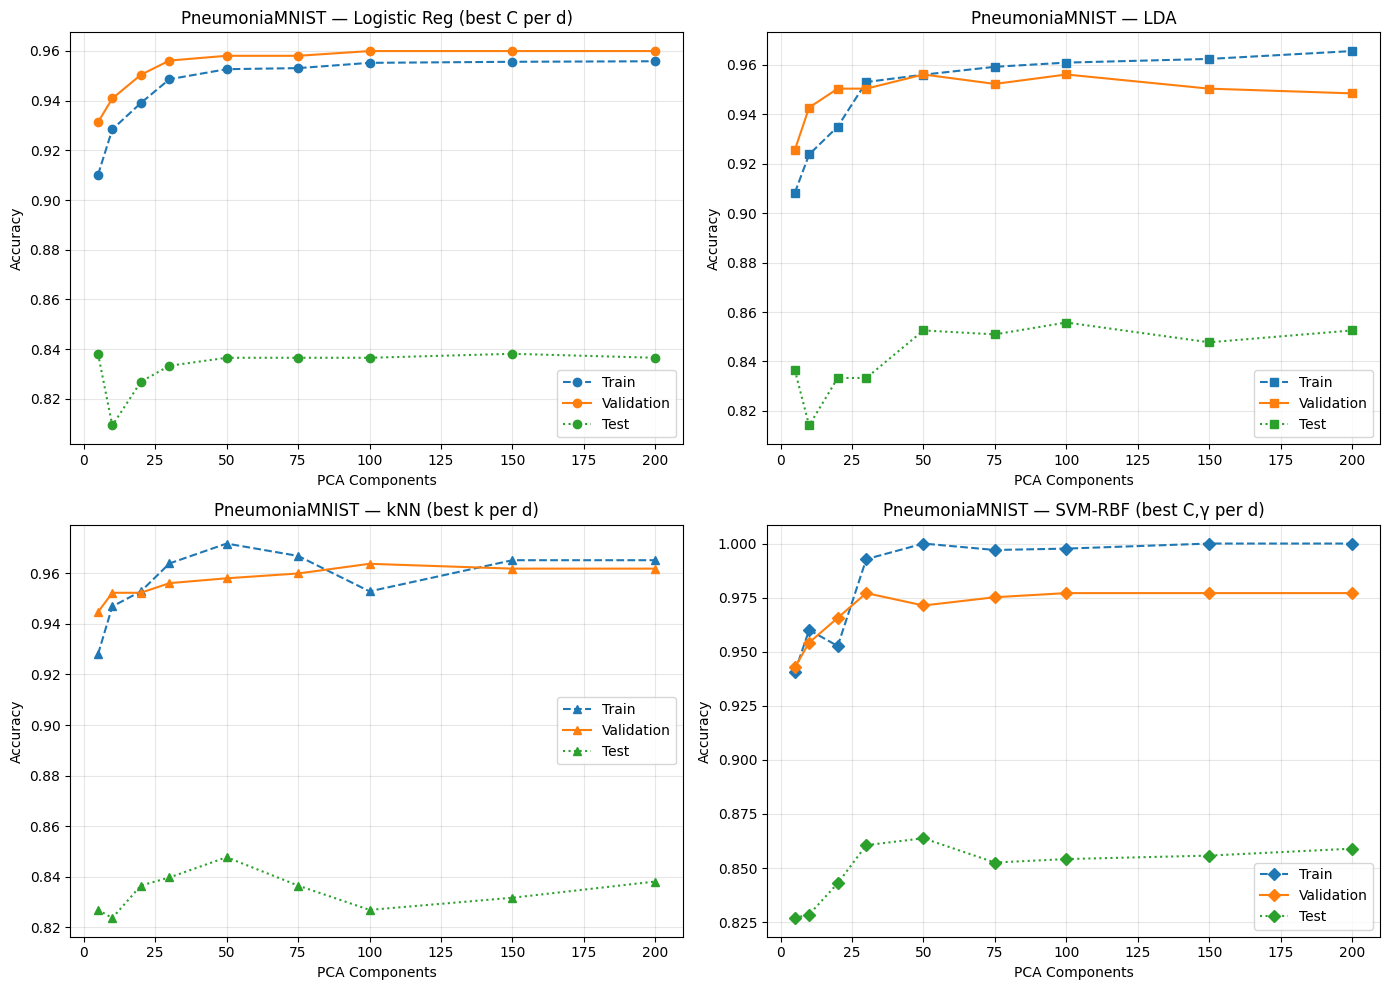

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(lr_best_pn['pca_dim'], lr_best_pn['train_acc'], 'o--', label='Train')
ax.plot(lr_best_pn['pca_dim'], lr_best_pn['val_acc'], 'o-', label='Validation')
ax.plot(lr_best_pn['pca_dim'], lr_best_pn['test_acc'], 'o:', label='Test')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Accuracy')
ax.set_title('PneumoniaMNIST — Logistic Reg (best C per d)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(lda_best_pn['pca_dim'], lda_best_pn['train_acc'], 's--', label='Train')
ax.plot(lda_best_pn['pca_dim'], lda_best_pn['val_acc'], 's-', label='Validation')
ax.plot(lda_best_pn['pca_dim'], lda_best_pn['test_acc'], 's:', label='Test')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Accuracy')
ax.set_title('PneumoniaMNIST — LDA')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(knn_best_pn['pca_dim'], knn_best_pn['train_acc'], '^--', label='Train')
ax.plot(knn_best_pn['pca_dim'], knn_best_pn['val_acc'], '^-', label='Validation')
ax.plot(knn_best_pn['pca_dim'], knn_best_pn['test_acc'], '^:', label='Test')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Accuracy')
ax.set_title('PneumoniaMNIST — kNN (best k per d)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(svm_best_pn['pca_dim'], svm_best_pn['train_acc'], 'D--', label='Train')
ax.plot(svm_best_pn['pca_dim'], svm_best_pn['val_acc'], 'D-', label='Validation')
ax.plot(svm_best_pn['pca_dim'], svm_best_pn['test_acc'], 'D:', label='Test')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Accuracy')
ax.set_title('PneumoniaMNIST — SVM-RBF (best C,γ per d)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Section 7: PCA Eigenimages and Reconstruction Quality

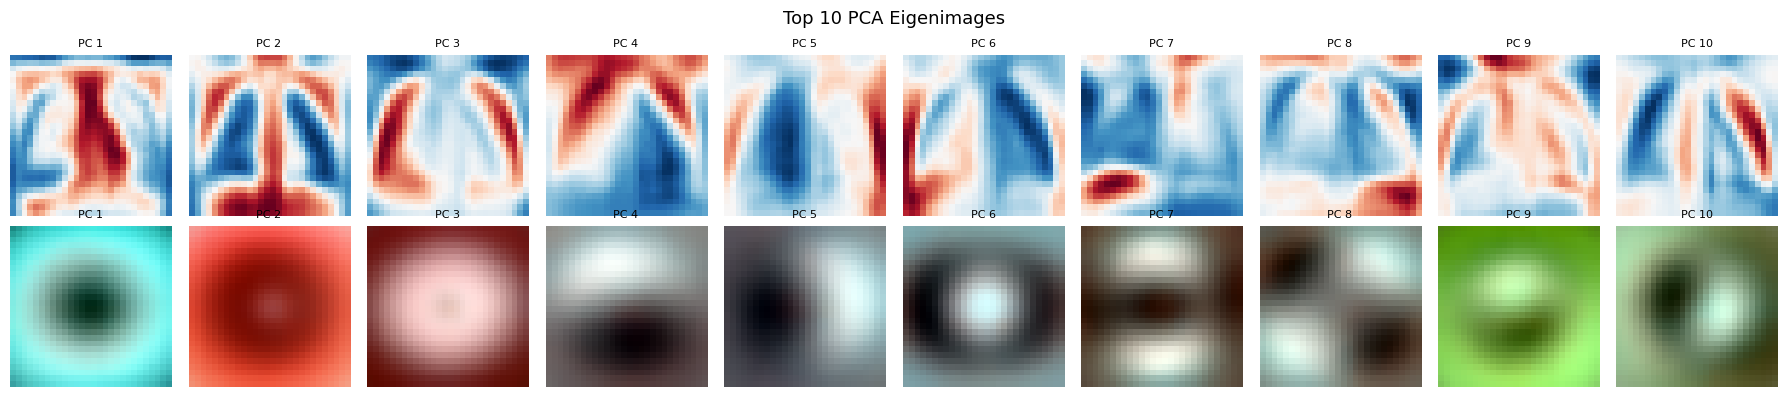

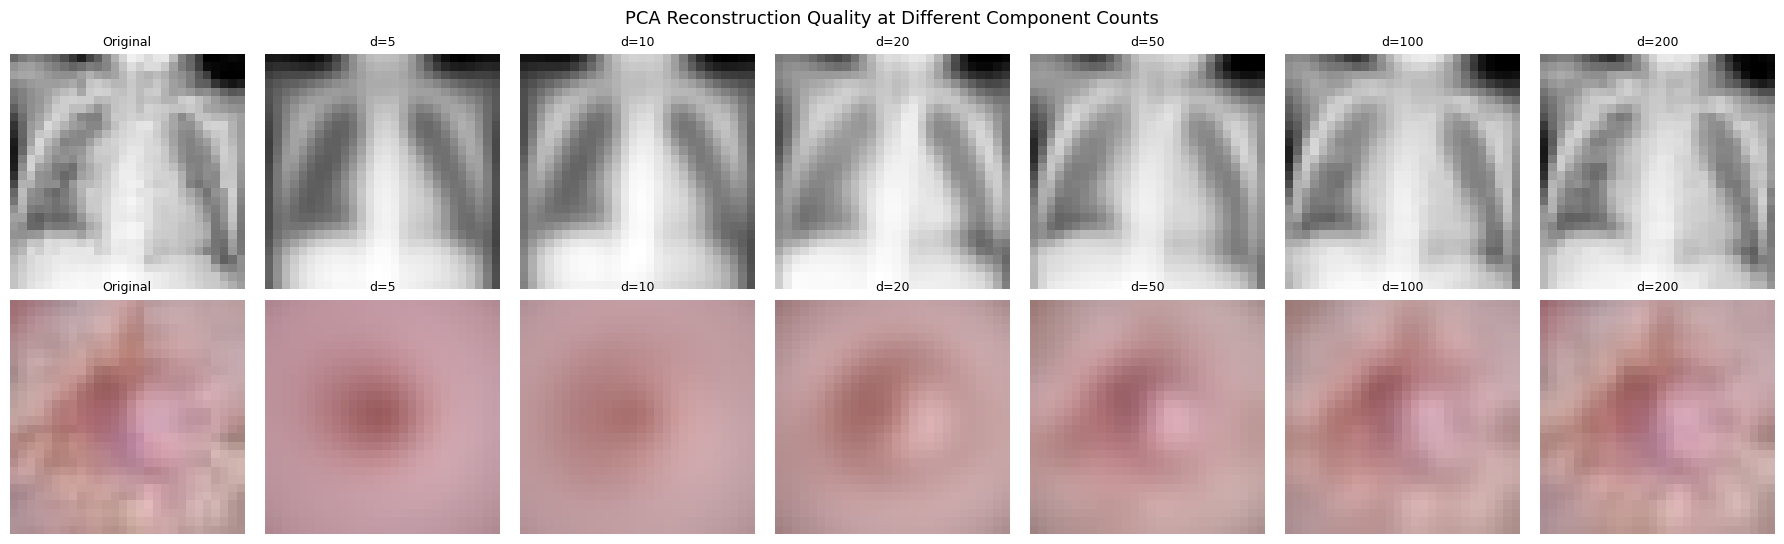

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))

pca_pn = PCA(n_components=10, random_state=42).fit(pn_train_scaled)
for i in range(10):
    ax = axes[0, i]
    eigenimg = pca_pn.components_[i].reshape(28, 28)
    ax.imshow(eigenimg, cmap='RdBu_r')
    ax.set_title(f'PC {i+1}', fontsize=8)
    ax.axis('off')
axes[0, 0].set_ylabel('Pneumonia', fontsize=10)

pca_dm = PCA(n_components=10, random_state=42).fit(dm_train_scaled)
for i in range(10):
    ax = axes[1, i]
    eigenimg = pca_dm.components_[i].reshape(28, 28, 3)
    eigenimg = (eigenimg - eigenimg.min()) / (eigenimg.max() - eigenimg.min())
    ax.imshow(eigenimg)
    ax.set_title(f'PC {i+1}', fontsize=8)
    ax.axis('off')
axes[1, 0].set_ylabel('Derma', fontsize=10)

plt.suptitle('Top 10 PCA Eigenimages', fontsize=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 7, figsize=(18, 5.5))

sample_idx_pn = 0
sample_idx_dm = 0

recon_dims = [5, 10, 20, 50, 100, 200]

axes[0, 0].imshow(pn_train_imgs[sample_idx_pn].squeeze(), cmap='gray')
axes[0, 0].set_title('Original', fontsize=9)
axes[0, 0].axis('off')

for j, d in enumerate(recon_dims):
    pca_temp = PCA(n_components=d, random_state=42).fit(pn_train_scaled)
    compressed = pca_temp.transform(pn_train_scaled[sample_idx_pn:sample_idx_pn+1])
    reconstructed = pca_temp.inverse_transform(compressed)
    reconstructed = pn_scaler.inverse_transform(reconstructed).reshape(28, 28)
    reconstructed = np.clip(reconstructed, 0, 255)
    axes[0, j+1].imshow(reconstructed, cmap='gray')
    axes[0, j+1].set_title(f'd={d}', fontsize=9)
    axes[0, j+1].axis('off')

axes[1, 0].imshow(dm_train_imgs[sample_idx_dm])
axes[1, 0].set_title('Original', fontsize=9)
axes[1, 0].axis('off')

for j, d in enumerate(recon_dims):
    pca_temp = PCA(n_components=d, random_state=42).fit(dm_train_scaled)
    compressed = pca_temp.transform(dm_train_scaled[sample_idx_dm:sample_idx_dm+1])
    reconstructed = pca_temp.inverse_transform(compressed)
    reconstructed = dm_scaler.inverse_transform(reconstructed).reshape(28, 28, 3)
    reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)
    axes[1, j+1].imshow(reconstructed)
    axes[1, j+1].set_title(f'd={d}', fontsize=9)
    axes[1, j+1].axis('off')

plt.suptitle('PCA Reconstruction Quality at Different Component Counts', fontsize=13)
plt.tight_layout()
plt.show()

# Section 8: HOG and LBP Feature Extraction & Classifier Comparison

In [ ]:
from skimage.feature import hog, local_binary_pattern
def extract_hog_features(images, is_color=False):
    """Extract HOG features from a set of images."""
    features = []
    for img in images:
        if is_color:
            gray = np.mean(img, axis=2).astype(np.uint8)
        else:
            gray = img.squeeze()
        feat = hog(gray, orientations=9, pixels_per_cell=(4, 4),
                   cells_per_block=(2, 2), feature_vector=True)
        features.append(feat)
    return np.array(features)

def extract_lbp_features(images, is_color=False, radius=2, n_points=16):
    features = []
    for img in images:
        if is_color:
            gray = np.mean(img, axis=2).astype(np.uint8)
        else:
            gray = img.squeeze()
        lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
        n_bins = n_points + 2
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
        features.append(hist)
    return np.array(features)

print("Extracting HOG features...")
hog_pn_train = extract_hog_features(pn_train_imgs, is_color=False)
hog_pn_val = extract_hog_features(pn_val_imgs, is_color=False)
hog_pn_test = extract_hog_features(pn_test_imgs, is_color=False)

hog_dm_train = extract_hog_features(dm_train_imgs, is_color=True)
hog_dm_val = extract_hog_features(dm_val_imgs, is_color=True)
hog_dm_test = extract_hog_features(dm_test_imgs, is_color=True)
print(f"PneumoniaMNIST HOG shape: {hog_pn_train.shape}")
print(f"DermaMNIST HOG shape: {hog_dm_train.shape}")

print("\nExtracting LBP features...")
lbp_pn_train = extract_lbp_features(pn_train_imgs, is_color=False)
lbp_pn_val = extract_lbp_features(pn_val_imgs, is_color=False)
lbp_pn_test = extract_lbp_features(pn_test_imgs, is_color=False)

lbp_dm_train = extract_lbp_features(dm_train_imgs, is_color=True)
lbp_dm_val = extract_lbp_features(dm_val_imgs, is_color=True)
lbp_dm_test = extract_lbp_features(dm_test_imgs, is_color=True)
print(f"PneumoniaMNIST LBP shape: {lbp_pn_train.shape}")
print(f"DermaMNIST LBP shape: {lbp_dm_train.shape}")

hog_pn_scaler = StandardScaler()
hog_pn_train_s = hog_pn_scaler.fit_transform(hog_pn_train)
hog_pn_val_s = hog_pn_scaler.transform(hog_pn_val)
hog_pn_test_s = hog_pn_scaler.transform(hog_pn_test)

hog_dm_scaler = StandardScaler()
hog_dm_train_s = hog_dm_scaler.fit_transform(hog_dm_train)
hog_dm_val_s = hog_dm_scaler.transform(hog_dm_val)
hog_dm_test_s = hog_dm_scaler.transform(hog_dm_test)

lbp_pn_scaler = StandardScaler()
lbp_pn_train_s = lbp_pn_scaler.fit_transform(lbp_pn_train)
lbp_pn_val_s = lbp_pn_scaler.transform(lbp_pn_val)
lbp_pn_test_s = lbp_pn_scaler.transform(lbp_pn_test)

lbp_dm_scaler = StandardScaler()
lbp_dm_train_s = lbp_dm_scaler.fit_transform(lbp_dm_train)
lbp_dm_val_s = lbp_dm_scaler.transform(lbp_dm_val)
lbp_dm_test_s = lbp_dm_scaler.transform(lbp_dm_test)

print("\nAll features extracted and standardized.")

Extracting HOG features...
  PneumoniaMNIST HOG shape: (4708, 1296)
  DermaMNIST HOG shape: (7007, 1296)

Extracting LBP features...
  PneumoniaMNIST LBP shape: (4708, 18)
  DermaMNIST LBP shape: (7007, 18)

All features extracted and standardized.
